# 1. Importar Librerías

In [1]:
! pip install --user plotly

In [2]:
! pip install --user seaborn

In [3]:
import pandas as pd
import numpy as np

# Librería 1: Matplotlib — visualizaciones básicas y control total
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Librería 2: Seaborn — visualizaciones estadísticas
import seaborn as sns

# Librería 3: Plotly — gráficos interactivos
import plotly.express as px
import plotly.graph_objects as go

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


# 2. Carga de datos

Para el presente proyecto se utilizarán dos recursos con el objetivo de responder a las preguntas planteadas mediante distintos métodos gráficos. Un primer dataset extraido del siguiente link "https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv", y un segundo conjunto de datos obtenido de un GitHub, donde se han clasificado las canciones desde los años 60 hasta los 2010s como hit(1) o flop(1).

Un flop es un fracaso. 

### 2.1 Carga de archivos csv

A parte de cargar los datos se hará un pequeño estudio del formato que presentan.

In [4]:
URL_DATASET = 'https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv'

datafram_sporify = pd.read_csv(URL_DATASET)
datafram_sporify.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [5]:
datafram_sporify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

### 2.2 Spotify Hit Predictor Dataset (GitHub)

Fuente: `github.com/fortyTwo102/The-Spotify-Hit-Predictor-Dataset`

Dentro de este dataset hay que tener en cuenta que está clasificado por decadas, por lo que descargaremos todos y los concatenaremos para obtener un histórico.

In [6]:
URL_2 = 'https://raw.githubusercontent.com/fortyTwo102/The-Spotify-Hit-Predictor-Dataset/master/'

# Nombre de todos los csv del repositorio
DECADAS = {
    '1960s': 'dataset-of-60s.csv',
    '1970s': 'dataset-of-70s.csv',
    '1980s': 'dataset-of-80s.csv',
    '1990s': 'dataset-of-90s.csv',
    '2000s': 'dataset-of-00s.csv',
    '2010s': 'dataset-of-10s.csv',
}

archivos = [] # Necesitamos guardar todos los datos antes de concatenarlos en un dataframe

for decada, archivo in DECADAS.items():
    url = URL_2 + archivo # Cogemos cada csv con su url para poder leerlo y así coger su información

    try:
        tmp = pd.read_csv(url)
        tmp['decada'] = decada
        archivos.append(tmp)
    except Exception as e:
        print(f'{decada}: no se ha descargado por {e}')

dataframe_hits = pd.concat(archivos, ignore_index=True)

In [7]:
dataframe_hits.head(3)

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,decada
0,Jealous Kind Of Fella,Garland Green,spotify:track:1dtKN6wwlolkM8XZy2y9C1,0.417,0.620,3,-7.727,1,0.0403,0.490,0.000000,0.0779,0.845,185.655,173533,3,32.94975,9,1,1960s
1,Initials B.B.,Serge Gainsbourg,spotify:track:5hjsmSnUefdUqzsDogisiX,0.498,0.505,3,-12.475,1,0.0337,0.018,0.107000,0.1760,0.797,101.801,213613,4,48.82510,10,0,1960s
2,Melody Twist,Lord Melody,spotify:track:6uk8tI6pwxxdVTNlNOJeJh,0.657,0.649,5,-13.392,1,0.0380,0.846,0.000004,0.1190,0.908,115.940,223960,4,37.22663,12,0,1960s


In [8]:
dataframe_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41106 entries, 0 to 41105
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track             41106 non-null  object 
 1   artist            41106 non-null  object 
 2   uri               41106 non-null  object 
 3   danceability      41106 non-null  float64
 4   energy            41106 non-null  float64
 5   key               41106 non-null  int64  
 6   loudness          41106 non-null  float64
 7   mode              41106 non-null  int64  
 8   speechiness       41106 non-null  float64
 9   acousticness      41106 non-null  float64
 10  instrumentalness  41106 non-null  float64
 11  liveness          41106 non-null  float64
 12  valence           41106 non-null  float64
 13  tempo             41106 non-null  float64
 14  duration_ms       41106 non-null  int64  
 15  time_signature    41106 non-null  int64  
 16  chorus_hit        41106 non-null  float6

Para poder plantearnos las preguntas antes vamos a visualizar que columnas coinciden en ambos dataframes.

In [9]:
# Cogemos las columnas de ambas tablas y las ordenamos para comprobar cuales coinciden
columnas = sorted(set(dataframe_hits.columns) | set(datafram_sporify.columns))

tabla_coinciden = pd.DataFrame(
    {
        'spotify' : [col in datafram_sporify.columns for col in columnas],
        'github' : [col in dataframe_hits.columns for col in columnas],
    },
    index= columnas
)

tabla_coinciden['coinciden'] = tabla_coinciden['spotify'] & tabla_coinciden['github']
tabla_coinciden


,spotify,github,coinciden
Unnamed: 0,True,False,False
acousticness,True,True,True
album_name,True,False,False
artist,False,True,False
artists,True,False,False
chorus_hit,False,True,False
danceability,True,True,True
decada,False,True,False
duration_ms,True,True,True
energy,True,True,True


Se puede apreciar que existen columnas que coinciden en ambos dataset, como: acousticness --> acústica, danceability --> capacidad de bailar esa canción, duration_ms --> duración de cada canción en milisegundos,...
Todas las columnas que coincidan se juntarán en un solo array para trabajar mejor con los datos que coinciden.

In [10]:
COLUMNAS_EN_COMUN = sorted(set(datafram_sporify.columns) & set(dataframe_hits))

for col in COLUMNAS_EN_COMUN:
    print(f'{col}')

acousticness
danceability
duration_ms
energy
instrumentalness
key
liveness
loudness
mode
speechiness
tempo
time_signature
valence


# 3. Limpieza y preprocesad de los dataframes

In [11]:
# Elminamos canciones que estén duplicadas si coinciden dos id's
datafram_sporify = datafram_sporify.drop_duplicates(subset='track_id')

# Eliminamos valores vacíos de las columnas más relevantes del dataset
datafram_sporify = datafram_sporify.dropna(subset=['track_name', 'artists', 'popularity', 'track_genre'])

# Añadimos la columna de minutos para saber mejor su duración
datafram_sporify['duration_min'] = (datafram_sporify['duration_ms'] / 60000).round(2)

In [12]:
# Al ver los nombres de las columnas del datafram de github, hay una columna que no deja claro lo que es
# así que cambiamos el nombre para que sea más legible.
# Mapeamos los valores de la columna target para saber si son un hit o un fracaso.
dataframe_hits['resultado'] = dataframe_hits['target'].map({1:'Hit', 0:'Flop'})

# Añadimos la columna de minutos para saber mejor su duración
dataframe_hits['duration_min'] = (dataframe_hits['duration_ms'] / 60000).round(2)

# 4. Preguntas

### Pregunta 1: ¿Qué caracteriza a la música de cada época?

Al hablar de épocas podemos utilzizar nuestro dataset que esta dividido en décadas (dataframe_hits). Dandonos una pequeña idea de que estilo de música se escuchaba en cada rango de años.
Para poder dar una respuesta clara, necesitamos saber ver el perfil sonoro que pueden llegar a tener las canciones en cada momento. Utilizaremos columnas como la acústica presenta en las canciones (acousticness), si la canción era bailable o no (danceability), la energía que transmitía (energy) y otras más.

- acousticness (0–1) — Probabilidad de que la canción sea acústica. Cerca de 1 significa sin instrumentos electrónicos ni producción digital, como una guitarra española o un piano solo.
- danceability (0–1) — Lo "bailable" que es una canción. Combina tempo, estabilidad del ritmo, fuerza del beat y regularidad. Un reggaetón puntúa alto, una balada lenta puntúa bajo.
- energy (0–1) — Intensidad y actividad percibida. Una canción de metal tiene energy alta, un tema ambient tiene energy baja. Mide volumen, timbre, velocidad y ruido general.
- valence (0–1) — Positividad emocional. Cerca de 1 suena alegre y eufórico, cerca de 0 suena triste o melancólico.
- speechiness (0–1) — Cuánta palabra hablada tiene. Por encima de 0.66 es casi todo voz (podcast, spoken word), entre 0.33–0.66 hay mucha letra o rap, por debajo de 0.33 es mayormente instrumental o cantada.
- instrumentalness (0–1) — Probabilidad de que no haya voces. Cerca de 1 significa puramente instrumental, cerca de 0 tiene voces claras.
- liveness (0–1) — Probabilidad de que sea una grabación en directo. Por encima de 0.8 es casi seguro un concierto en vivo.
- loudness (dB, negativo) — Volumen medio en decibelios. Va típicamente de -60 a 0. Más cerca de 0 = más alto. Esta es la única que no va de 0 a 1, así que en tu gráfico puede que necesites normalizarla.
- chorus_hit (segundos) — En qué segundo de la canción empieza el primer estribillo. Es exclusiva del dataset de GitHub, no la calcula Spotify directamente.

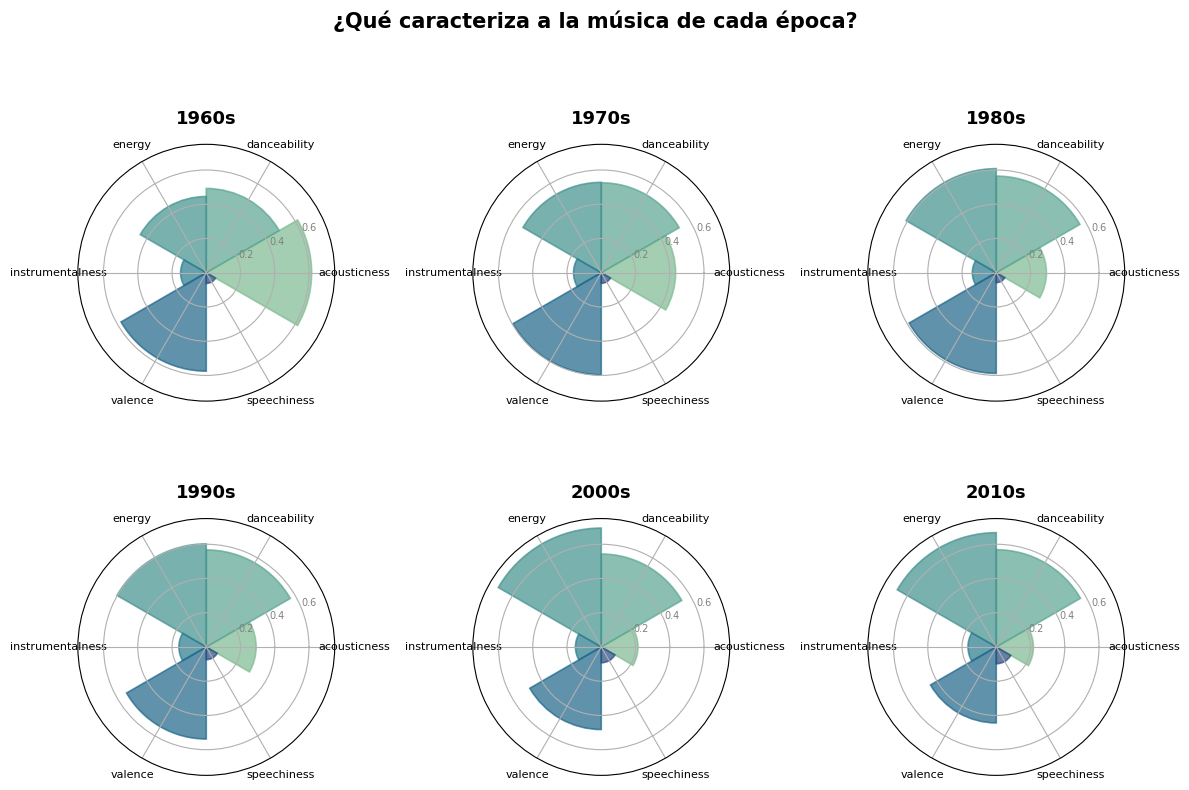

In [13]:
columnas = ["acousticness", "danceability", "energy", "instrumentalness", "valence", "speechiness"]

dataframe_hits_media = dataframe_hits.groupby('decada')[columnas].mean()

fig, ax = plt.subplots(2, 3, figsize=(12, 8), subplot_kw=dict(polar=True))
ax = ax.flatten()

# linspace(empieza desde, acaba en, cantidad de puntos, tiene endpoint)
x_coords = np.linspace(0, 2*np.pi, len(columnas), endpoint=False)
width = 2*np.pi / len(columnas)

colores = sns.color_palette("crest", len(columnas))

for i, (decada, fila) in enumerate(dataframe_hits_media.iterrows()):
    axes = ax[i]
    val = fila.values

    bars = axes.bar(x_coords, val, width=width, color=colores, alpha=0.7, edgecolor=colores, linewidth=1.2)

    axes.set_xticks(x_coords)
    axes.set_xticklabels(columnas, fontsize=8)

    axes.set_ylim(0, 0.75)
    axes.set_yticks([0.2, 0.4, 0.6])
    axes.set_yticklabels(['0.2', '0.4', '0.6'], fontsize=7, color='gray')

    axes.set_title(decada, fontsize=13, fontweight='bold', pad=15)

plt.suptitle('¿Qué caracteriza a la música de cada época?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En el primer gráfico se eligió loudness y chorus-hit, el problema es que los valores de estas dos columnas no varian entre 0-1 como las demás sino que son números grandes o negativos. Además, se ha eliminado la columna liveness, porque lo único que nos daba de información es si esa canción era de un concierto en vivo o una grabación.

Página de apoyo para realizar este gráfico: `https://cookieblues.medium.com/how-to-make-a-nightingale-rose-diagram-only-using-matplotlib-c581441e8cc4`

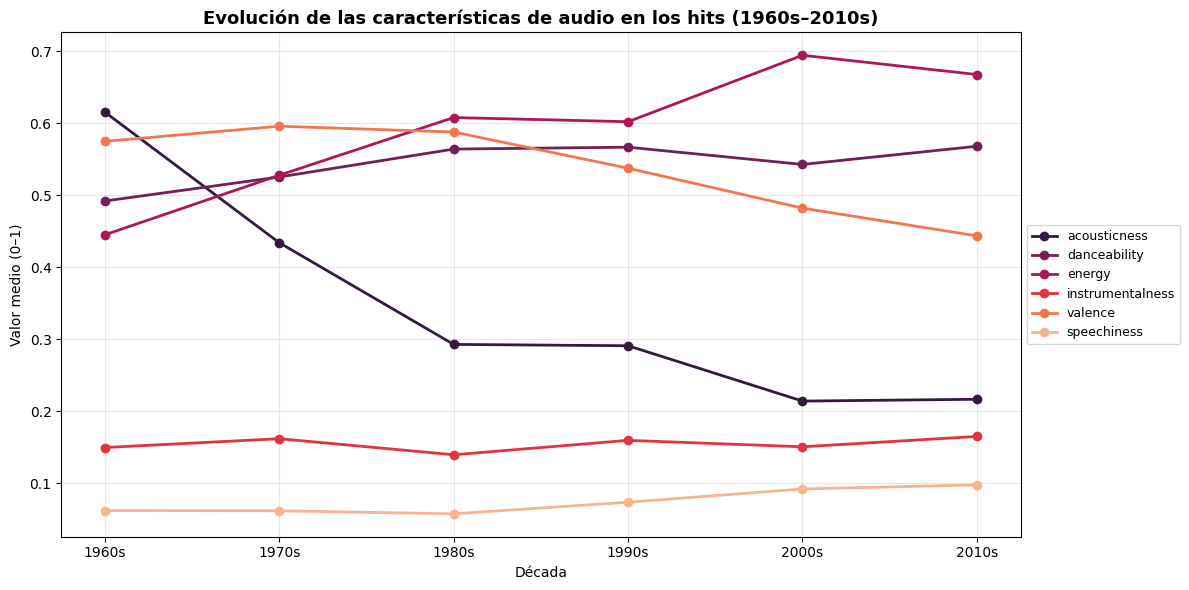

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colores = sns.color_palette("rocket")

for i, info in enumerate(columnas):
    ax.plot(dataframe_hits_media.index, dataframe_hits_media[info], color=colores[i], marker='o', linewidth=2, label=info)

ax.set_title('Evolución de las características de audio en los hits (1960s–2010s)', fontsize=13, fontweight='bold')

ax.set_xlabel('Década')
ax.set_ylabel('Valor medio (0–1)')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Pregunta 2: ¿Qué hace que una canción se vuelva popular?

### Pregunta 3: ¿Los hits de los 60-90s y 2000 suenan como los hits de ahora?

# 5. Conclusiones

# 6. Declaración de uso de IA